Successfully set font to 'Nirmala UI' to support Hindi characters.
Using device: cuda
Vocabulary Size: 93


C:\Users\Adit Punamiya\AppData\Local\Temp\ipykernel_17096\1491208189.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_lo

Model loaded successfully from 'handwriting_model_pytorch_v2.pth'

--- Displaying 10 random predictions ---


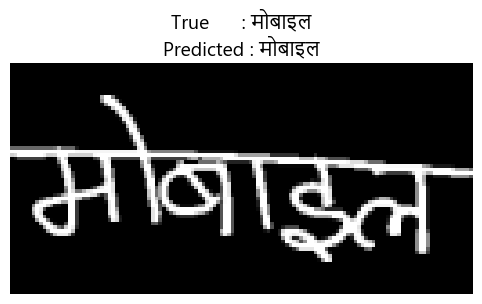

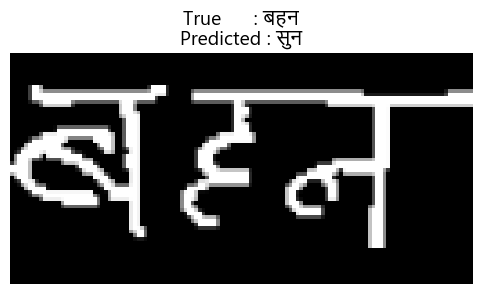

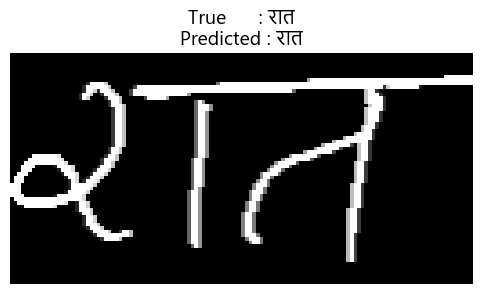

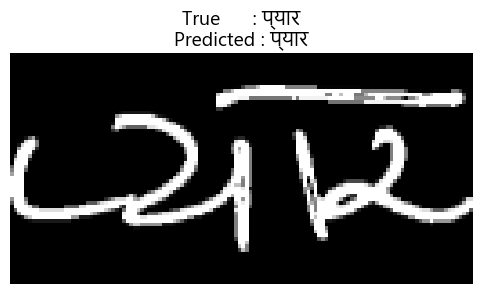

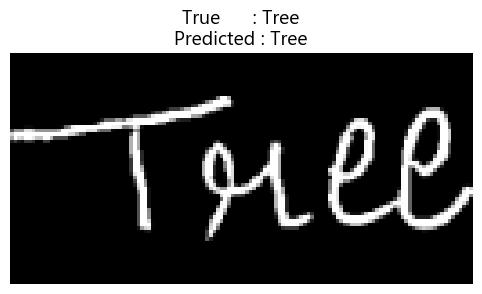

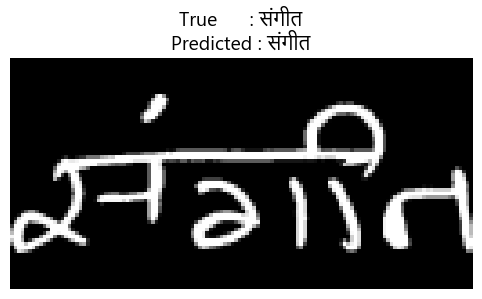

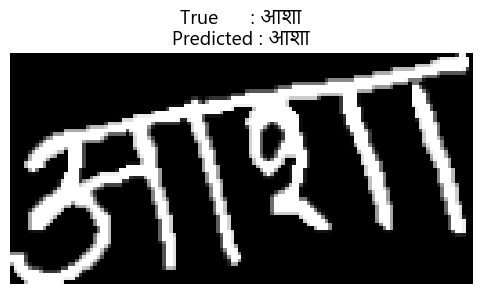

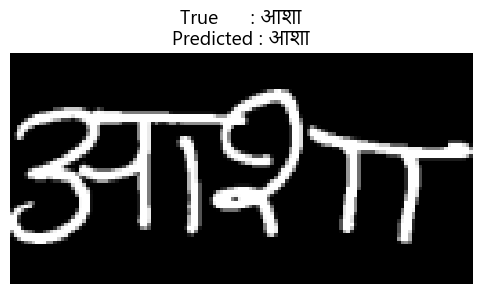

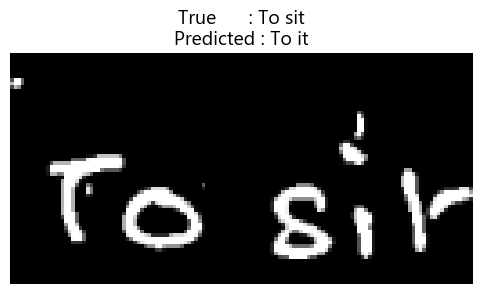

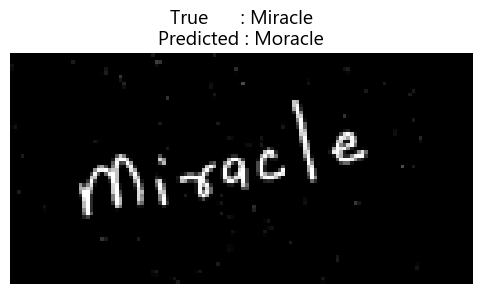

In [1]:
# --- 1. IMPORTS AND FONT SETUP ---
import torch
import torch.nn as nn
from torchvision import transforms
import pandas as pd
import random
import os
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import font_manager

# This will search for a font that supports Hindi on your system.
# 'Nirmala UI' is a good candidate for Windows.
font_name = 'Nirmala UI'
try:
    # Find the font and set it as the default for all plots
    font_prop = font_manager.FontProperties(family=font_name)
    plt.rcParams['font.family'] = font_name
    print(f"Successfully set font to '{font_name}' to support Hindi characters.")
except Exception as e:
    print(f"Warning: Could not find the font '{font_name}'. Hindi characters may not display correctly.")
    print("Please install a font that supports Devanagari (like 'Nirmala UI' or 'Noto Sans Devanagari').")
    print(f"Matplotlib error: {e}")


# --- 2. MODEL AND CONFIG DEFINITION ---
# This configuration must match the one used during training
class Config:
    PROCESSED_DATA_DIR = "data"
    LABELS_FILE = os.path.join(PROCESSED_DATA_DIR, "labels.csv")
    CHARACTERS_FILE = os.path.join(PROCESSED_DATA_DIR, "characters.txt")
    IMG_HEIGHT = 64

# The model architecture must be defined to load the weights
class CRNN(nn.Module):
    def __init__(self, num_chars):
        super(CRNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.bridge = nn.Linear(64 * (Config.IMG_HEIGHT // 4), 64)
        self.rnn = nn.LSTM(64, 128, num_layers=2, bidirectional=True, dropout=0.25, batch_first=True)
        self.output = nn.Linear(256, num_chars) # 128 * 2 for bidirectional

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 3, 1, 2)
        b, w, c, h = x.size()
        x = x.reshape(b, w, c * h)
        x = self.bridge(x)
        x, _ = self.rnn(x)
        x = self.output(x)
        return nn.functional.log_softmax(x, dim=2)


# --- 3. LOAD MODEL AND VOCABULARY ---
# Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load Vocabulary
with open(Config.CHARACTERS_FILE, "r", encoding="utf-8") as f:
    characters = [line.rstrip('\n') for line in f.readlines()]

num_to_char = {i + 1: char for i, char in enumerate(characters)}
num_to_char[0] = ''  # Blank token
vocab_size = len(characters) + 1
print(f"Vocabulary Size: {vocab_size}")

# Load Model
model_path = "handwriting_model_pytorch_v2.pth"
model = CRNN(num_chars=vocab_size).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()  # Set the model to evaluation mode
print(f"Model loaded successfully from '{model_path}'")


# --- 4. PREDICTION FUNCTION ---
def predict_image(image_path, model, device, num_to_char):
    """Preprocesses an image, gets a prediction from the model, and decodes it."""
    
    # Preprocess the image
    image = Image.open(image_path).convert("L")
    transform = transforms.Compose([
        transforms.Resize((Config.IMG_HEIGHT, 400)), 
        transforms.ToTensor()
    ])
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Get prediction
    with torch.no_grad():
        preds = model(image_tensor)
    
    # Decode prediction using CTC greedy decoding
    pred_indices = torch.argmax(preds, dim=2)
    last_char_idx = -1
    pred_text = ''
    for idx in pred_indices[0]:
        if idx.item() != 0 and idx.item() != last_char_idx:
            if idx.item() in num_to_char:
                pred_text += num_to_char[idx.item()]
        last_char_idx = idx.item()
        
    return image, pred_text


# --- 5. RUN THE TEST ---
# Load the labels file to get image paths and true labels
df = pd.read_csv(Config.LABELS_FILE)

print("\n--- Displaying 10 random predictions ---")
for _ in range(10):
    # Select a random image
    idx = random.randint(0, len(df) - 1)
    image_path = df.iloc[idx]['image_path']
    true_label = str(df.iloc[idx]['label'])
    
    # Get the prediction
    original_image, predicted_label = predict_image(image_path, model, device, num_to_char)
    
    # Display the result
    plt.figure(figsize=(12, 3))
    plt.imshow(original_image, cmap='gray')
    plt.title(f'True      : {true_label}\nPredicted : {predicted_label}', fontsize=14)
    plt.axis('off')
    plt.show()


In [3]:
# --- 1. IMPORTS ---
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import os

# --- 2. CONFIG AND MODEL DEFINITION (Must match training script) ---
class Config:
    CHARACTERS_FILE = os.path.join("data", "characters.txt")
    IMG_HEIGHT = 64

class CRNN(nn.Module):
    def __init__(self, num_chars):
        super(CRNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.bridge = nn.Linear(64 * (Config.IMG_HEIGHT // 4), 64)
        self.rnn = nn.LSTM(64, 128, num_layers=2, bidirectional=True, dropout=0.25, batch_first=True)
        self.output = nn.Linear(256, num_chars)

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 3, 1, 2)
        b, w, c, h = x.size()
        x = x.reshape(b, w, c * h)
        x = self.bridge(x)
        x, _ = self.rnn(x)
        x = self.output(x)
        return nn.functional.log_softmax(x, dim=2)

# --- 3. PREDICTION FUNCTION ---
def predict_image(image: Image.Image, model, device, num_to_char) -> str:
    """Preprocesses an image, gets a prediction, and decodes it."""
    image = image.convert("L")
    transform = transforms.Compose([
        transforms.Resize((Config.IMG_HEIGHT, 400)), 
        transforms.ToTensor()
    ])
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        preds = model(image_tensor)
    
    pred_indices = torch.argmax(preds, dim=2)
    last_char_idx = -1
    pred_text = ''
    for idx in pred_indices[0]:
        if idx.item() != 0 and idx.item() != last_char_idx:
            if idx.item() in num_to_char:
                pred_text += num_to_char[idx.item()]
        last_char_idx = idx.item()
    return pred_text

# --- 4. MAIN EXECUTION ---

# IMPORTANT: Change this to the path of the image you want to test
IMAGE_TO_TEST = r"handwriting_dataset\style_9\hindi\43.png" 

# --- Setup and Load Everything ---
print("--- Initializing ---")
device = torch.device("cpu")

# Load Vocabulary
if not os.path.exists(Config.CHARACTERS_FILE):
     raise FileNotFoundError(f"Error: '{Config.CHARACTERS_FILE}' not found. Please run 'prepare_dataset.py' first.")
with open(Config.CHARACTERS_FILE, "r", encoding="utf-8") as f:
    characters = [line.rstrip('\n') for line in f.readlines()]
num_to_char = {i + 1: char for i, char in enumerate(characters)}
num_to_char[0] = ''
vocab_size = len(characters) + 1

# Load Model
model_path = "handwriting_model_pytorch_v2.pth"
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Error: Model file '{model_path}' not found. Please train the model first.")
model = CRNN(num_chars=vocab_size).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print("--- Model and vocabulary loaded successfully ---")


# --- Predict and Print ---
if not os.path.exists(IMAGE_TO_TEST):
    print(f"Error: The test image '{IMAGE_TO_TEST}' was not found. Please update the path.")
else:
    # Load the single image
    input_image = Image.open(IMAGE_TO_TEST)
    
    # Get the prediction
    predicted_text = predict_image(input_image, model, device, num_to_char)
    
    # Print the final answer
    print("\n" + "="*30)
    print(f"Image Path: {IMAGE_TO_TEST}")
    print(f"Predicted Text: {predicted_text}")
    print("="*30)


--- Initializing ---
--- Model and vocabulary loaded successfully ---

Image Path: handwriting_dataset\style_9\hindi\43.png
Predicted Text: ख्रसी


C:\Users\Adit Punamiya\AppData\Local\Temp\ipykernel_17096\2835518659.py:82: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_lo